# AEP Load & Weather Data Pipeline

This notebook builds a clean hourly PJM AEP load and Columbus weather dataset through data ingestion, timestamp alignment, aggregation, DST handling, and exploratory analysis. The final output is a structured dataset for downstream forecasting and energy market analytics.

## 1. Project Goal

The workflow focuses on preprocessing and validation steps required for time-series energy data, including timezone alignment, hourly aggregation, weather integration, and seasonality exploration.

## 2. Data Loading

Load the PJM hourly load files for 2024 and 2025 and the Columbus hourly weather file.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-whitegrid')

USE_SNOWFLAKE = False  # Set True to read from Snowflake instead of local CSV files.

SNOWFLAKE_QUERY = '''
SELECT *
FROM MART_AEP_MARKET_HOURLY
ORDER BY DATETIME
'''

def read_market_mart_from_snowflake():
    import os
    from pathlib import Path

    try:
        import snowflake.connector
    except ImportError:
        fallback_path = Path('../outputs/master_market_df_from_snowflake.csv')
        if fallback_path.exists():
            print('snowflake.connector is not installed in this notebook kernel; using exported Snowflake mart CSV instead.')
            df = pd.read_csv(fallback_path)
            df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
            return df.sort_values('datetime').reset_index(drop=True)
        raise ImportError(
            'snowflake.connector is not installed in this notebook kernel. '
            'Switch the notebook kernel to snowflake_env, install snowflake-connector-python in this kernel, '
            'or run scripts/query_market_mart.py first to create outputs/master_market_df_from_snowflake.csv.'
        )

    try:
        from dotenv import load_dotenv
        load_dotenv('../.env')
    except ImportError:
        pass

    conn = snowflake.connector.connect(
        account=os.environ['SNOWFLAKE_ACCOUNT'],
        user=os.environ['SNOWFLAKE_USER'],
        password=os.environ['SNOWFLAKE_PASSWORD'],
        role=os.getenv('SNOWFLAKE_ROLE', 'ACCOUNTADMIN'),
        warehouse=os.getenv('SNOWFLAKE_WAREHOUSE', 'PJM_WH'),
        database=os.getenv('SNOWFLAKE_DATABASE', 'PJM_MARKET_DB'),
        schema=os.getenv('SNOWFLAKE_SCHEMA', 'ANALYTICS'),
    )
    try:
        cur = conn.cursor()
        try:
            cur.execute(SNOWFLAKE_QUERY)
            columns = [col[0].lower() for col in cur.description]
            rows = cur.fetchall()
        finally:
            cur.close()
    finally:
        conn.close()

    df = pd.DataFrame(rows, columns=columns)
    df.columns = df.columns.str.lower()
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    return df.sort_values('datetime').reset_index(drop=True)


Loaded 2 load files and weather file
Load file columns: ['datetime_beginning_utc', 'datetime_beginning_ept', 'nerc_region', 'mkt_region', 'zone', 'load_area', 'mw', 'is_verified']
Weather file columns: ['time', 'temperature_2m (°C)']


/var/folders/yd/h0rh3srn2634qw945z8lpjkr0000gq/T/ipykernel_12661/3447694459.py:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


## 3. Data Cleaning

Standardize column names and prepare datetimes for both the load and weather datasets. This ensures consistent merging on hourly timestamps, which is critical for forecasting accuracy.

In [16]:
if not USE_SNOWFLAKE:
    clean_load_dfs = []
    for df in load_dfs:
        df_clean = df.rename(columns={
            'datetime_beginning_ept': 'datetime_ept',
            'datetime_beginning_utc': 'datetime_utc',
            'mw': 'load_mw'
        })
        clean_load_dfs.append(df_clean)

    weather = weather_raw.copy()
    weather.columns = weather.columns.str.strip().str.lower().str.replace(' ', '_', regex=False)
    weather = weather.rename(columns={'temperature_2m_(°c)': 'temperature_2m', 'time': 'datetime'})

    print('Cleaned load columns:', clean_load_dfs[0].columns.tolist())
    print('Cleaned weather columns:', weather.columns.tolist())
else:
    print('Using Snowflake mart; local load/weather raw cleaning is skipped.')


Cleaned load columns: ['datetime_utc', 'datetime_ept', 'nerc_region', 'mkt_region', 'zone', 'load_area', 'load_mw', 'is_verified']
Cleaned weather columns: ['datetime', 'temperature_2m']


## 4. Load Aggregation

Combine the 2024 and 2025 PJM load datasets and aggregate AEP sub-area load into a single total AEP hourly load. Chronological ordering is enforced so the time series is ready for analysis.

In [17]:
if not USE_SNOWFLAKE:
    load_combined = pd.concat(clean_load_dfs, ignore_index=True)

    load_combined['datetime_ept'] = pd.to_datetime(load_combined['datetime_ept'], format='%m/%d/%Y %I:%M:%S %p', errors='coerce')
    load_combined = load_combined.dropna(subset=['datetime_ept'])
    # Keep local Eastern time alignment; both datasets use the same local hour basis.
    # This avoids DST ambiguity while preserving the hourly merge logic.
    load_combined['datetime_ept'] = load_combined['datetime_ept']

    # Aggregate total AEP zone load by hour across load areas.
    load_agg = (
        load_combined
        .groupby('datetime_ept', as_index=False)['load_mw']
        .sum()
    )

    load_agg = load_agg.sort_values('datetime_ept').reset_index(drop=True)

    print('Aggregated load rows:', len(load_agg))
    print('Load time range:', load_agg['datetime_ept'].min(), 'to', load_agg['datetime_ept'].max())
    print(load_agg.head())
else:
    print('Using Snowflake mart; local AEP load aggregation is skipped.')


Aggregated load rows: 11662
         datetime_ept    load_mw
0 2024-01-01 00:00:00  13510.539
1 2024-01-01 01:00:00  13392.585
2 2024-01-01 02:00:00  13317.742
3 2024-01-01 03:00:00  13242.742
4 2024-01-01 04:00:00  13392.619


## 5. Weather Preparation

Prepare the Columbus weather dataset by keeping the hourly temperature field, parsing timestamps, and aligning the timezone format with PJM data. Accurate weather alignment is essential because temperature is a key driver of electricity demand.

In [18]:
if not USE_SNOWFLAKE:
    weather = weather[['datetime', 'temperature_2m']].copy()
    weather['datetime'] = pd.to_datetime(weather['datetime'], format='%Y-%m-%dT%H:%M', errors='coerce')
    weather = weather.dropna(subset=['datetime'])
    # Keep local Eastern time alignment for the weather timestamps.
    weather['datetime'] = weather['datetime']
    weather = weather.sort_values('datetime').reset_index(drop=True)

    weather['temperature_2m'] = pd.to_numeric(weather['temperature_2m'], errors='coerce')
    print('Weather rows after cleaning:', len(weather))
    print('Weather time range:', weather['datetime'].min(), 'to', weather['datetime'].max())
    print(weather.head())
else:
    print('Using Snowflake mart; local weather preparation is skipped.')


Weather rows after cleaning: 11664
             datetime  temperature_2m
0 2024-01-01 00:00:00            -0.4
1 2024-01-01 01:00:00            -0.6
2 2024-01-01 02:00:00            -0.6
3 2024-01-01 03:00:00            -0.6
4 2024-01-01 04:00:00            -0.4


## 6. Data Merging

Merge the aggregated AEP load data with hourly Columbus weather observations. The merged dataset will contain the aligned features needed for energy demand analytics and future forecasting.

Note: the merged dataset is limited to the overlapping hourly period between PJM load data and Columbus weather observations. Because timestamps are aligned in local Eastern time, the combined hourly index may omit the single skipped spring-forward hour during DST transitions.

In [19]:
if not USE_SNOWFLAKE:
    load_for_merge = load_agg.rename(columns={'datetime_ept': 'datetime'}).copy()
    load_for_merge['datetime'] = pd.to_datetime(load_for_merge['datetime'], errors='coerce')
    weather['datetime'] = pd.to_datetime(weather['datetime'], errors='coerce')

    market_df = pd.merge(
        load_for_merge,
        weather,
        on='datetime',
        how='left'
    )

    market_df = market_df[['datetime', 'load_mw', 'temperature_2m']].copy()
    market_df = market_df.sort_values('datetime').reset_index(drop=True)
else:
    market_df = market_df[['datetime', 'load_mw', 'temperature_2m']].copy()
    market_df = market_df.sort_values('datetime').reset_index(drop=True)

missing_weather = market_df['temperature_2m'].isna().sum()
print('Final merged rows before filtering:', len(market_df))
print('Missing temperature observations:', missing_weather)
if not USE_SNOWFLAKE:
    print('Weather time range:', weather['datetime'].min(), 'to', weather['datetime'].max())

# Keep only hours with both load and aligned temperature data for a clean forecasting dataset.
market_df = market_df.dropna(subset=['temperature_2m']).reset_index(drop=True)
print('Final merged rows after filtering to available weather:', len(market_df))

expected_hours = pd.date_range(
    start=market_df['datetime'].min(),
    end=market_df['datetime'].max(),
    freq='h'
)
# Any missing hours here are expected where local Eastern time skips a clock hour during DST spring-forward.
missing_hours = expected_hours.difference(market_df['datetime'])

print('Expected hourly rows:', len(expected_hours))
print('Actual rows:', len(market_df))
print('Missing hourly timestamps:', len(missing_hours))
if len(missing_hours) > 0:
    print(missing_hours[:10])
print(market_df.head())
print('Duplicate timestamps:', market_df['datetime'].duplicated().sum())
print(market_df[['load_mw', 'temperature_2m']].describe())


Final merged rows before filtering: 11662
Missing temperature observations: 0
Weather time range: 2024-01-01 00:00:00 to 2025-04-30 23:00:00
Final merged rows after filtering to available weather: 11662
Expected hourly rows: 11664
Actual rows: 11662
Missing hours: 2
DatetimeIndex(['2024-03-10 02:00:00', '2025-03-09 02:00:00'], dtype='datetime64[ns]', freq=None)
             datetime    load_mw  temperature_2m
0 2024-01-01 00:00:00  13510.539            -0.4
1 2024-01-01 01:00:00  13392.585            -0.6
2 2024-01-01 02:00:00  13317.742            -0.6
3 2024-01-01 03:00:00  13242.742            -0.6
4 2024-01-01 04:00:00  13392.619            -0.4
Duplicate timestamps: 0
            load_mw  temperature_2m
count  11662.000000     11662.00000
mean   15142.949998        10.87828
std     2339.022803        10.72100
min    10047.126000       -20.00000
25%    13490.548500         2.50000
50%    14771.445000        11.10000
75%    16582.711250        19.60000
max    23725.561000        35.

## 7. Exploratory Data Analysis (EDA)

Explore the cleaned merged dataset with time-series plots and seasonality analysis to understand how load responds to temperature and weekly patterns.

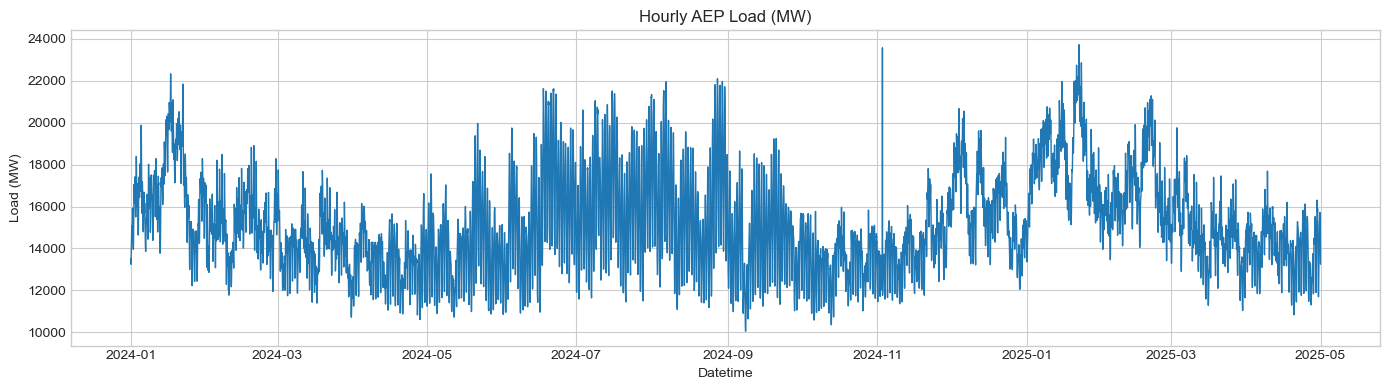

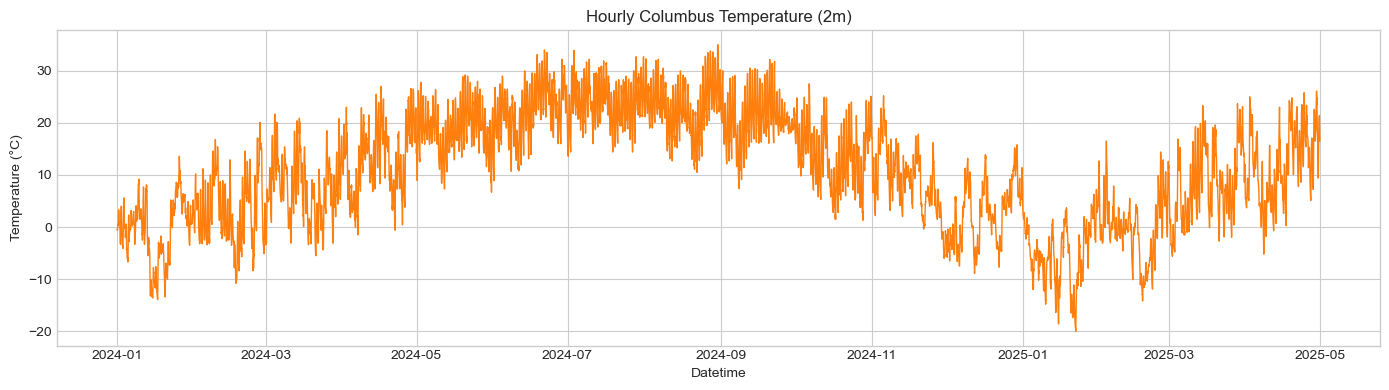

In [20]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(market_df['datetime'], market_df['load_mw'], color='tab:blue', linewidth=1)
ax.set_title('Hourly AEP Load (MW)')
ax.set_xlabel('Datetime')
ax.set_ylabel('Load (MW)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(market_df['datetime'], market_df['temperature_2m'], color='tab:orange', linewidth=1)
ax.set_title('Hourly Columbus Temperature (2m)')
ax.set_xlabel('Datetime')
ax.set_ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()


### Temperature relationship

The scatter plot reveals a clear U-shaped relationship between temperature and electricity demand. Load levels are generally lower during mild spring and fall conditions, while both extremely cold and hot temperatures are associated with higher demand due to heating and cooling usage. This pattern also explains why the linear correlation between load and temperature appears relatively weak despite temperature being one of the most important drivers of electricity demand.

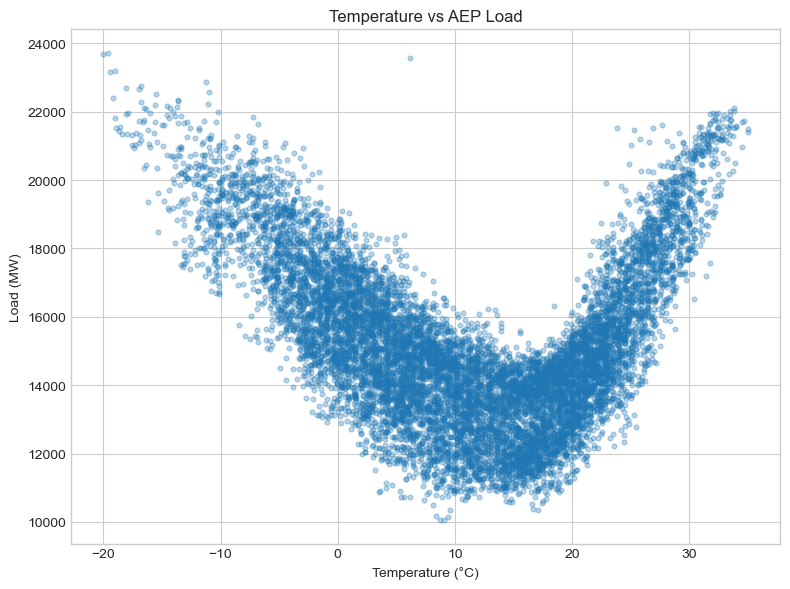

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(market_df['temperature_2m'], market_df['load_mw'], alpha=0.3, s=12)
ax.set_title('Temperature vs AEP Load')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Load (MW)')
plt.tight_layout()
plt.show()


### Correlation table

Quantifying the relationships between load, temperature, and hour helps identify the strongest drivers of demand. Strong correlations support the use of these features in operational load forecasting.

                 load_mw  temperature_2m      hour
load_mw         1.000000       -0.196847  0.301684
temperature_2m -0.196847        1.000000  0.167679
hour            0.301684        0.167679  1.000000


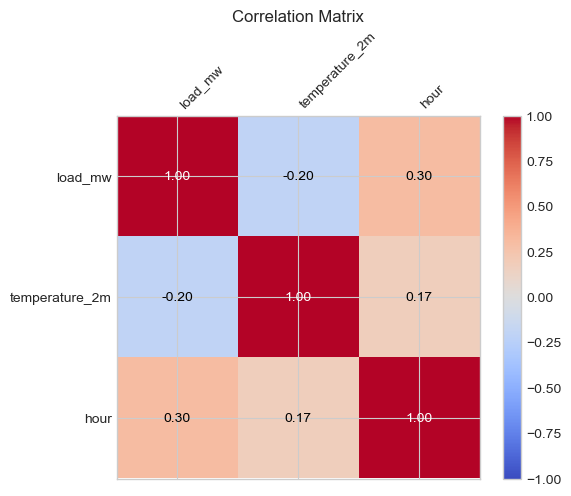

In [22]:
market_df['hour'] = market_df['datetime'].dt.hour
market_df['month'] = market_df['datetime'].dt.month
corr_data = market_df[['load_mw', 'temperature_2m', 'hour']].corr()
print(corr_data)

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(corr_data, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax, ax=ax)
ax.set_xticks(range(len(corr_data.columns)))
ax.set_yticks(range(len(corr_data.index)))
ax.set_xticklabels(corr_data.columns, rotation=45, ha='left')
ax.set_yticklabels(corr_data.index)
for i in range(len(corr_data.index)):
    for j in range(len(corr_data.columns)):
        ax.text(j, i, f'{corr_data.iloc[i, j]:.2f}', ha='center', va='center', color='white' if abs(corr_data.iloc[i, j]) > 0.5 else 'black')
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Monthly seasonality

Monthly average load highlights the seasonal energy market cycle. Higher winter and summer loads support the operational view that heating and cooling are the primary seasonal demand drivers, while spring and fall are the softest demand periods.

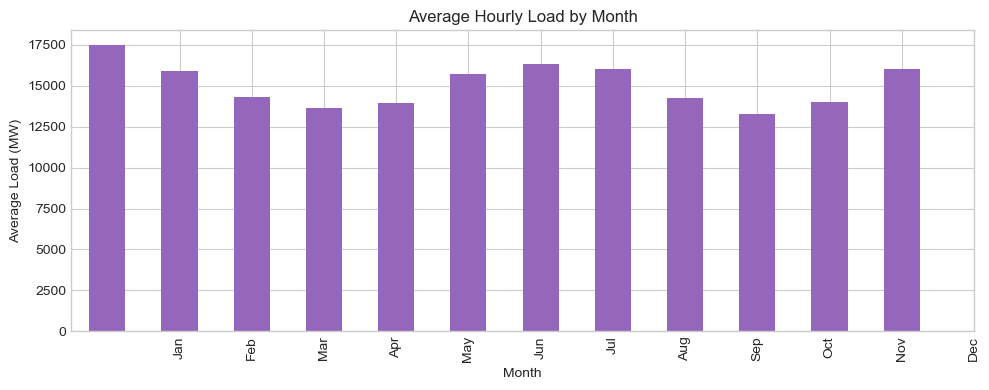

In [23]:
monthly_load = market_df.groupby('month')['load_mw'].mean()
fig, ax = plt.subplots(figsize=(10, 4))
monthly_load.plot(kind='bar', color='tab:purple', ax=ax)
ax.set_title('Average Hourly Load by Month')
ax.set_xlabel('Month')
ax.set_ylabel('Average Load (MW)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

### Seasonality Patterns

Analyze daily and weekly seasonality to capture recurring demand patterns that are important for operational forecasting and load scheduling. The hourly profile highlights when peak dispatch is likely needed in the late afternoon and evening, while weekday/weekend differences reflect commercial and industrial activity.

### Cyclical hour encoding

A simple plot of `sin_hour` and `cos_hour` shows why cyclical encoding is useful for hourly demand modeling: 23:00 and 00:00 are adjacent in time, even though they are far apart as integer values.

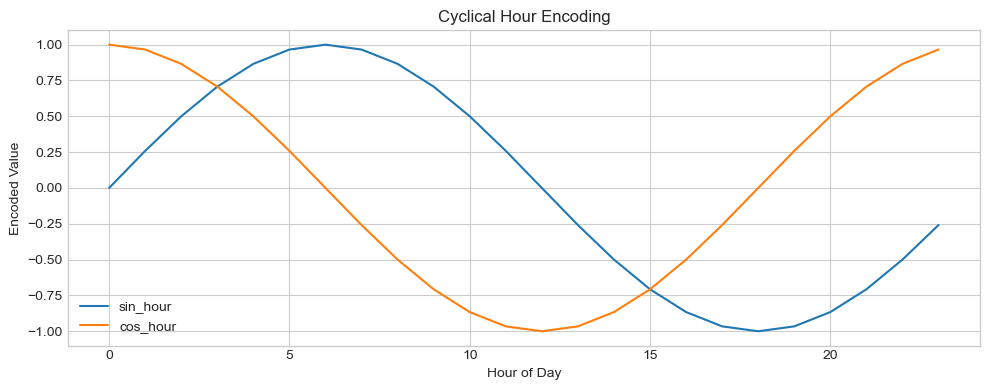

Cyclical hour encoding transforms the hourly feature into a continuous periodic representation. This avoids treating 23:00 and 00:00 as distant integer values and better captures the repeating daily demand cycle observed in electricity load behavior.


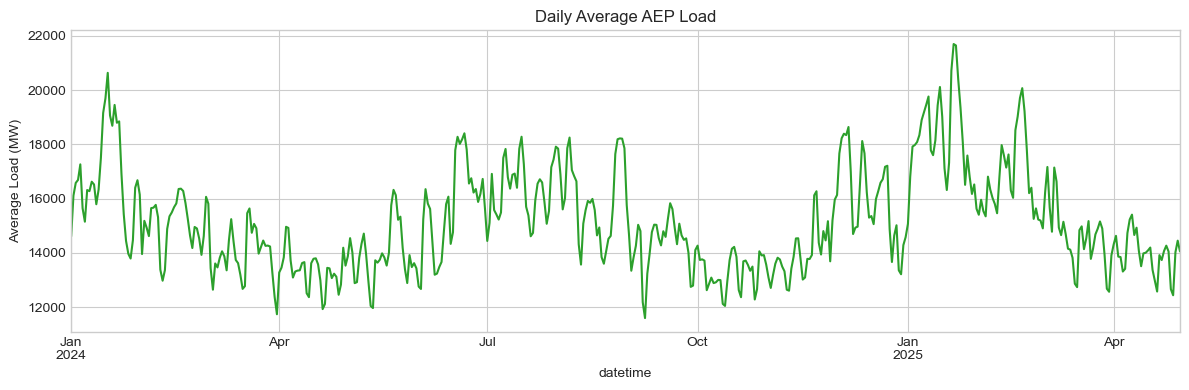

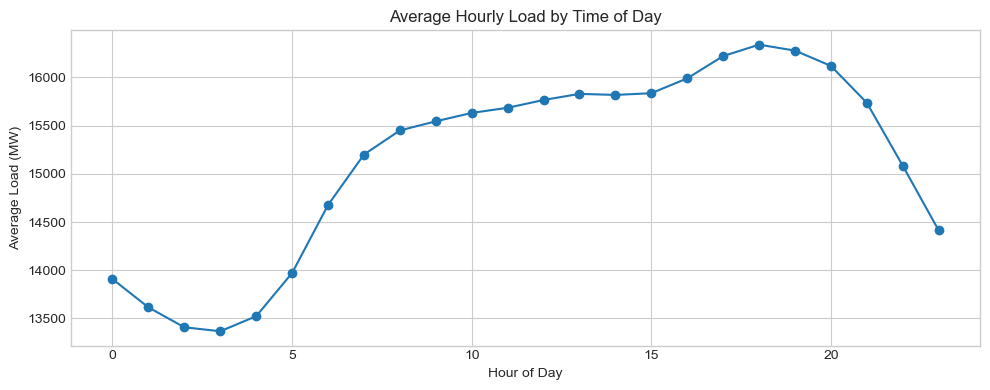

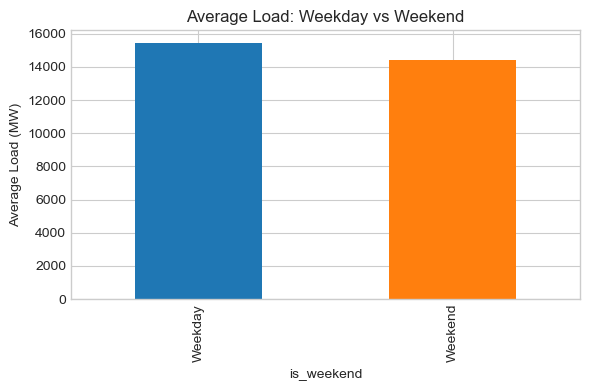

In [24]:
market_df['date'] = market_df['datetime'].dt.date
market_df['hour'] = market_df['datetime'].dt.hour
market_df['weekday'] = market_df['datetime'].dt.day_name()
market_df['is_weekend'] = market_df['datetime'].dt.dayofweek >= 5

# Encode hour as a cyclical feature for advanced forecasting models.
# 23:00 and 00:00 are adjacent on the clock, so sine/cosine encoding preserves that relationship.
market_df['sin_hour'] = np.sin(2 * np.pi * market_df['hour'] / 24)
market_df['cos_hour'] = np.cos(2 * np.pi * market_df['hour'] / 24)

hour_encoding = pd.DataFrame({'hour': range(24)})
hour_encoding['sin_hour'] = np.sin(2 * np.pi * hour_encoding['hour'] / 24)
hour_encoding['cos_hour'] = np.cos(2 * np.pi * hour_encoding['hour'] / 24)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hour_encoding['hour'], hour_encoding['sin_hour'], label='sin_hour')
ax.plot(hour_encoding['hour'], hour_encoding['cos_hour'], label='cos_hour')
ax.set_title('Cyclical Hour Encoding')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Encoded Value')
ax.legend()
plt.tight_layout()
plt.show()

print('Cyclical hour encoding transforms the hourly feature into a continuous periodic representation. This avoids treating 23:00 and 00:00 as distant integer values and better captures the repeating daily demand cycle observed in electricity load behavior.')

daily_mean = market_df.set_index('datetime')['load_mw'].resample('D').mean()
weekly_profile = market_df.groupby('hour')['load_mw'].mean()
weekday_weekend = market_df.groupby('is_weekend')['load_mw'].mean().rename({False: 'Weekday', True: 'Weekend'})

fig, ax = plt.subplots(figsize=(12, 4))
daily_mean.plot(ax=ax, color='tab:green')
ax.set_title('Daily Average AEP Load')
ax.set_ylabel('Average Load (MW)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
weekly_profile.plot(ax=ax, marker='o')
ax.set_title('Average Hourly Load by Time of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Load (MW)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
weekday_weekend.plot(kind='bar', ax=ax, color=['tab:blue', 'tab:orange'])
ax.set_title('Average Load: Weekday vs Weekend')
ax.set_ylabel('Average Load (MW)')
plt.tight_layout()
plt.show()


## 8. Initial Insights

- The cleaned dataset provides a single hourly view of total AEP load matched with Columbus temperature observations.
- Load exhibits clear daily cycles, monthly seasonality, and week/weekend differences, which are important features for forecasting.
- The U-shaped temperature-load relationship underscores both winter heating and summer cooling demand drivers.
- Average weekday load exceeds weekend load, consistent with higher commercial and industrial activity during working days.
- Ensuring timezone alignment and a consistent hourly index reduces the risk of introducing timing errors into forecast inputs.


## 9. Export Final Dataset

Save the merged clean dataset for the next stage of the forecasting workflow.

In [25]:
output_path = '../data/aep_load_weather_hourly_dataset.csv'
export_df = market_df[['datetime', 'load_mw', 'temperature_2m', 'sin_hour', 'cos_hour']].copy()
export_df.to_csv(output_path, index=False)
print(f'Saved clean merged dataset to {output_path}')

Saved clean merged dataset to ../data/aep_load_weather_hourly_dataset.csv


## Export Dashboard Outputs

Save the cleaned load-weather dataset and core EDA summaries/figures to `outputs/` so the project README, GitHub portfolio, and dashboard can reuse the same artifacts.

In [ ]:
from pathlib import Path

output_dir = Path('../outputs')
output_dir.mkdir(exist_ok=True)

# Stable dataset for downstream notebooks and dashboard use.
export_df = market_df[['datetime', 'load_mw', 'temperature_2m', 'sin_hour', 'cos_hour']].copy()
export_df.to_csv(output_dir / 'load_weather_hourly_dataset.csv', index=False)

# Summary tables.
load_weather_summary = market_df[['load_mw', 'temperature_2m']].describe().T
load_weather_summary.to_csv(output_dir / 'load_weather_summary.csv')

hourly_load_profile = market_df.groupby('hour')['load_mw'].mean().reset_index(name='avg_load_mw')
hourly_load_profile.to_csv(output_dir / 'hourly_load_profile.csv', index=False)

monthly_load_profile = market_df.groupby('month')['load_mw'].mean().reset_index(name='avg_load_mw')
monthly_load_profile.to_csv(output_dir / 'monthly_load_profile.csv', index=False)

# Presentation-ready figures.
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly_load_profile['hour'], hourly_load_profile['avg_load_mw'], marker='o', linewidth=2)
ax.set_title('Average AEP Load by Hour')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Load (MW)')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(output_dir / 'hourly_load_profile.png', dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(market_df['temperature_2m'], market_df['load_mw'], alpha=0.3, s=12)
ax.set_title('AEP Load vs Temperature')
ax.set_xlabel('Temperature')
ax.set_ylabel('Load (MW)')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(output_dir / 'load_vs_temperature.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Saved load/weather dashboard outputs to {output_dir.resolve()}')